# Machine Learning Pipeline for Non-Invasive BGL Estimation (Imputation Experiment)

## 🧪 Experiment Overview: Imputation-Based Retention vs. Hard Filtering
In this experimental notebook, rather than dropping sessions with low heart rate (< 60 BPM), high BGL (> 300 mg/dL), or signal processing anomalies, **all valid sessions are retained** in the dataset.
Extracted PPG optical features for flagged noisy/outlier sessions are set to `np.nan`. Missing feature values are imputed dynamically using fold-level `SimpleImputer` inside zero-leakage cross-validation.


In [6]:
print("starting")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis
from scipy.interpolate import interp1d
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from collections import Counter
import xgboost as xgb

try:
    import catboost as cb
    has_catboost = True
except ImportError:
    has_catboost = False

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

# Set style for modern aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

csv_path = "data/real/glucosense_r_dataset_2026-09-17.csv"
sampling_rate = 50  # 50 Hz acquisition rate
print(f"✓ Imports completed. CatBoost: {has_catboost}, LightGBM: {has_lightgbm}, XGBoost: True.")

# ==============================================================================
# Clarke Error Grid Analysis (Clinical Reliability Helpers)
# ==============================================================================
def clarke_zone(ref, pred):
    """Classify a single (ref, pred) glucose pair (mg/dL) into Clarke Error Grid zone (A, B, C, D, E)."""
    if (pred <= 70 and ref <= 70) or (pred <= 1.2 * ref and pred >= 0.8 * ref):
        return 'A'
    if ref >= 180 and pred <= 70:
        return 'E'
    if ref <= 70 and pred >= 180:
        return 'E'
    if ref >= 240 and pred >= 70 and pred <= 180:
        return 'C'
    if ref <= 70 and pred >= 70 and pred <= 180:
        return 'C'
    if (ref >= 130 and ref <= 180) and pred <= 70:
        return 'D'
    if ref <= 70 and pred >= 180:
        return 'D'
    if ref >= 240 and pred <= 70:
        return 'D'
    return 'B'

def clarke_zone_fractions(y_true, y_pred):
    """Return dict of zone -> percentage (0 to 100)."""
    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    total = len(zones) if len(zones) > 0 else 1
    return {z: (zones.count(z) / total) * 100 for z in ['A', 'B', 'C', 'D', 'E']}

def plot_clarke_grid(y_true, y_pred, title='', ax=None):
    """Plot publication-quality Clarke Error Grid on provided axes or new figure."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 400], [0, 400], 'k--', alpha=0.4, linewidth=1, label='Ideal 1:1 Line')
    ax.fill_between([0, 175, 400], [0, 105, 320], [0, 175, 400],
                    alpha=0.10, color='green', label='Zone A (Clinical Accuracy)')

    zone_colors = {
        'A': '#16a34a',
        'B': '#d97706',
        'C': '#ea580c',
        'D': '#dc2626',
        'E': '#9333ea'
    }

    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    for z, color in zone_colors.items():
        count = zones.count(z)
        if count > 0:
            yt = [y_true[i] for i in range(len(y_true)) if zones[i] == z]
            yp = [y_pred[i] for i in range(len(y_pred)) if zones[i] == z]
            ax.scatter(yt, yp, color=color, alpha=0.75, s=45, label=f'Zone {z} ({count})')

    fracs = clarke_zone_fractions(y_true, y_pred)
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 400)
    ax.set_xlabel('Reference BGL (mg/dL)', fontsize=11)
    ax.set_ylabel('Predicted BGL (mg/dL)', fontsize=11)

    zone_str = f"A: {fracs['A']:.1f}% | B: {fracs['B']:.1f}% | A+B: {fracs['A']+fracs['B']:.1f}%"
    ax.set_title(f"{title}\n{zone_str}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.25)
    return fracs
print("✓ Clarke Error Grid analysis module ready.")


starting
✓ Imports completed. CatBoost: True, LightGBM: True, XGBoost: True.
✓ Clarke Error Grid analysis module ready.


In [7]:
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset file not found at {csv_path}")

df = pd.read_csv(csv_path)
print(f"✓ Dataset loaded. Total records: {len(df)}")
print("\nFirst 3 rows:")
display(df.head(3))

print("\nSession kinds distribution:")
print(df['session_kind'].value_counts())

✓ Dataset loaded. Total records: 100

First 3 rows:


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,2026-08-06T09:03:50.335985+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",fasting,196,3500,57994;58030;58020;58027;58013;58039;58044;5805...
1,07dc95d8-8001-417f-b139-d4faf092b371,2026-08-06T10:34:31.431381+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",1hr_post_prandial,269,3500,59419;59453;59470;59475;59513;59507;59529;5956...
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,2026-08-27T07:56:02.871753+00:00,P002,63,Female,79.0,172.0,21,NaN,fasting,190,3500,55490;55479;55469;55480;55473;55469;55476;5548...



Session kinds distribution:
session_kind
fasting              46
2hr_post_prandial    31
1hr_post_prandial    23
Name: count, dtype: int64


In [8]:
def determine_ac_dc_from_PPG(signal):
    signal = np.asarray(signal, dtype=np.float64)
    if len(signal) == 0:
        return 0.0, 0.0, 0.0
    
    max_array = []
    min_array = []
    mid_value = float(np.mean(signal))
    max_value = mid_value
    min_value = mid_value
    max_index = 0
    min_index = 0
    
    for i in range(len(signal)):
        now_value = signal[i]
        if now_value > mid_value:
            if min_value < mid_value and min_index > 0:
                min_array.append(min_value)
                min_value = mid_value
            if now_value > max_value:
                max_value = now_value
                max_index = i
        if now_value < mid_value:
            if max_value > mid_value and max_index > 0:
                max_array.append(max_value)
                max_value = mid_value
            if now_value < min_value:
                min_value = now_value
                min_index = i

    ac_signal = float(np.mean(max_array) - np.mean(min_array)) if (len(max_array) > 0 and len(min_array) > 0) else 0.0
    dc_signal = mid_value
    ac_dc_ratio = float(ac_signal / (dc_signal + 1e-9)) if dc_signal != 0 else 0.0
    return ac_signal, dc_signal, ac_dc_ratio

def extract_paper_pulse_features(avg_beat):
    from scipy.stats import entropy

    peak_val = float(np.max(avg_beat))
    trough_val = float(np.min(avg_beat))
    peak_to_peak = peak_val - trough_val
    mean_val = float(np.mean(avg_beat))
    std_val = float(np.std(avg_beat))
    rms_val = float(np.sqrt(np.mean(avg_beat**2)))
    skew_val = float(skew(avg_beat))
    kurt_val = float(kurtosis(avg_beat))

    crest_factor = float(peak_val / (rms_val + 1e-5))
    impulse_factor = float(peak_val / (mean_val + 1e-5))
    median_diff = float(np.median(np.abs(np.diff(avg_beat))))
    slope = float(np.max(np.gradient(avg_beat)))

    fft_vals = np.abs(np.fft.rfft(avg_beat))**2
    psd_norm = fft_vals / (np.sum(fft_vals) + 1e-8)
    spec_entropy = float(entropy(psd_norm + 1e-12, base=2))

    raw_dict = {
        'peak_val': peak_val,
        'peak_to_peak': peak_to_peak,
        'mean_val': mean_val,
        'std_val': std_val,
        'rms_val': rms_val,
        'skewness': skew_val,
        'kurtosis': kurt_val,
        'crest_factor': crest_factor,
        'impulse_factor': impulse_factor,
        'median_diff': median_diff,
        'slope': slope,
        'spectral_entropy': spec_entropy
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def extract_apg_landmarks(avg_beat):
    vpg = np.gradient(avg_beat)
    apg = np.gradient(vpg)
    len_b = len(avg_beat)

    a_idx = np.argmax(apg[:int(len_b * 0.35)])
    a_val = apg[a_idx] if apg[a_idx] > 0 else 1e-5

    search_b_end = int(len_b * 0.5)
    if search_b_end > a_idx + 2:
        b_idx = a_idx + np.argmin(apg[a_idx:search_b_end])
        b_val = apg[b_idx]
    else:
        b_val = 0.0

    search_c_end = int(len_b * 0.65)
    if 'b_idx' in locals() and search_c_end > b_idx + 1:
        c_idx = b_idx + np.argmax(apg[b_idx:search_c_end])
        c_val = apg[c_idx]
    else:
        c_val = 0.0

    search_d_end = int(len_b * 0.8)
    if 'c_idx' in locals() and search_d_end > c_idx + 1:
        d_idx = c_idx + np.argmin(apg[c_idx:search_d_end])
        d_val = apg[d_idx]
    else:
        d_val = 0.0

    if 'd_idx' in locals() and len_b > d_idx + 1:
        e_idx = d_idx + np.argmax(apg[d_idx:])
        e_val = apg[e_idx]
    else:
        e_val = 0.0

    b_a = b_val / a_val
    c_a = c_val / a_val
    d_a = d_val / a_val
    e_a = e_val / a_val

    aging_index = (b_val - c_val - d_val - e_val) / a_val
    elasticity_index = (b_val - c_val - d_val) / a_val
    deceleration_index = (d_val - e_val) / a_val

    raw_dict = {
        'apg_a': a_val, 'apg_b': b_val, 'apg_c': c_val, 'apg_d': d_val, 'apg_e': e_val,
        'b_a_ratio': b_a, 'c_a_ratio': c_a, 'd_a_ratio': d_a, 'e_a_ratio': e_a,
        'aging_index': aging_index, 'elasticity_index': elasticity_index, 'deceleration_index': deceleration_index
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def process_session_with_averaging(ppg_raw, sampling_rate=50):
    cleaned = nk.ppg_clean(ppg_raw, sampling_rate=sampling_rate, method='elgendi')
    signals, info = nk.ppg_process(cleaned, sampling_rate=sampling_rate, method='elgendi')
    peaks = info['PPG_Peaks']
    hrv_df = nk.ppg_analyze(signals, sampling_rate=sampling_rate)

    if 'PPG_Rate' in signals.columns and not pd.isna(signals['PPG_Rate'].mean()):
        heart_rate = float(signals['PPG_Rate'].mean())
    elif 'PPG_Rate_Mean' in hrv_df.columns and not pd.isna(hrv_df['PPG_Rate_Mean'].values[0]):
        heart_rate = float(hrv_df['PPG_Rate_Mean'].values[0])
    elif len(peaks) >= 2:
        rr_intervals = np.diff(peaks) / sampling_rate
        heart_rate = float(60.0 / np.mean(rr_intervals))
    else:
        heart_rate = 0.0

    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 > 10:
            troughs.append(p1 + np.argmin(cleaned[p1:p2]))

    valid_beats = []
    target_len = 100
    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i+1]
        beat_len = t2 - t1
        if 18 <= beat_len <= 80:
            beat = cleaned[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-5:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))

    if len(valid_beats) < 3:
        avg_beat = np.zeros(target_len)
        num_valid_beats = 0
    else:
        valid_beats_arr = np.array(valid_beats)
        median_beat = np.median(valid_beats_arr, axis=0)
        corrs = [np.corrcoef(b, median_beat)[0, 1] for b in valid_beats_arr]
        clean_beats = [b for b, c in zip(valid_beats_arr, corrs) if c > 0.8]
        avg_beat = np.mean(clean_beats, axis=0) if len(clean_beats) >= 2 else median_beat
        num_valid_beats = len(clean_beats) if len(clean_beats) >= 2 else len(valid_beats)

    s_peak_idx = np.argmax(avg_beat)
    s_peak_val = avg_beat[s_peak_idx]
    if s_peak_idx + 5 < target_len - 10:
        d_peak_idx = s_peak_idx + 5 + np.argmax(avg_beat[s_peak_idx+5:target_len-5])
        d_peak_val = avg_beat[d_peak_idx]
    else:
        d_peak_val = 0.0

    vpg_avg = np.gradient(avg_beat)
    apg_avg = np.gradient(vpg_avg)

    # Compute Paper Pseudocode AC/DC features
    paper_ac, paper_dc, paper_ac_dc_ratio = determine_ac_dc_from_PPG(ppg_raw)
    paper_log_ac_dc_ratio = float(np.log(np.maximum(paper_ac_dc_ratio, 1e-9)))

    # Compute Perfusion Index (AC/DC Ratio %) using NeuroKit2
    try:
        nk_perf_series = nk.ppg_quality(cleaned, sampling_rate=sampling_rate, method='perfusion', ppg_raw=ppg_raw)
        nk_perf_mean = float(np.mean(nk_perf_series))
        nk_perf_std = float(np.std(nk_perf_series))
        nk_perf_median = float(np.median(nk_perf_series))
        nk_perf_max = float(np.max(nk_perf_series))
        nk_perf_min = float(np.min(nk_perf_series))
    except Exception:
        nk_perf_mean = nk_perf_std = nk_perf_median = nk_perf_max = nk_perf_min = 0.0

    dc_component = float(np.mean(ppg_raw))
    ac_pp_amp = float(np.max(cleaned) - np.min(cleaned))
    ac_std_val = float(np.std(cleaned))
    ac_dc_ratio_val = float(ac_pp_amp / (dc_component + 1e-9))
    ac_dc_ratio_std_val = float((2.0 * np.sqrt(2.0) * ac_std_val) / (dc_component + 1e-9))
    log_ac_dc_ratio_val = float(np.log(np.maximum(ac_dc_ratio_val, 1e-9)))

    avg_feats = {
        'paper_ac_signal': paper_ac,
        'paper_dc_signal': paper_dc,
        'paper_ac_dc_ratio': paper_ac_dc_ratio,
        'paper_log_ac_dc_ratio': paper_log_ac_dc_ratio,
        'nk_perfusion_mean': nk_perf_mean,
        'nk_perfusion_std': nk_perf_std,
        'nk_perfusion_median': nk_perf_median,
        'nk_perfusion_max': nk_perf_max,
        'nk_perfusion_min': nk_perf_min,
        'dc_component': dc_component,
        'ac_pp_amplitude': ac_pp_amp,
        'ac_dc_ratio': ac_dc_ratio_val,
        'ac_dc_ratio_std': ac_dc_ratio_std_val,
        'log_ac_dc_ratio': log_ac_dc_ratio_val,
        'computed_heart_rate': heart_rate,
        'num_valid_beats': num_valid_beats,
        'avg_ppg_amp': s_peak_val,
        'avg_ppg_skew': skew(avg_beat),
        'avg_ppg_kurt': kurtosis(avg_beat),
        'avg_vpg_amp': np.max(vpg_avg) - np.min(vpg_avg),
        'avg_vpg_max_upstroke': np.max(vpg_avg),
        'avg_vpg_skew': skew(vpg_avg),
        'avg_apg_amp': np.max(apg_avg) - np.min(apg_avg),
        'avg_apg_skew': skew(apg_avg),
        'reflection_index': d_peak_val / (s_peak_val + 1e-5),
    }

    avg_feats.update(extract_paper_pulse_features(avg_beat))
    avg_feats.update(extract_apg_landmarks(avg_beat))

    for col in hrv_df.columns:
        val = hrv_df[col].values[0]
        if not pd.isna(val):
            avg_feats[col] = val

    return avg_feats, heart_rate

# ── Hybrid Config: DROP High BGL Outliers (>300) & IMPUTE Bad PPG Signals ──
MIN_HEART_RATE = 60.0  # Threshold for valid Heart Rate (BPM)
MAX_BGL = 300.0        # Threshold for typical BGL range (mg/dL)

features_list = []
flagged_sessions = []
dropped_high_bgl_list = []
skipped_missing = 0
skipped_high_bgl = 0
retained_imputed_hr = 0
retained_imputed_err = 0

initial_rows = len(df)
print("Extracting features: DROPPING High BGL outliers (> 300 mg/dL) & IMPUTING Bad Signals...")
print(f"Parameters: MIN_HEART_RATE = {MIN_HEART_RATE} BPM, MAX_BGL = {MAX_BGL} mg/dL")

for idx, row in df.iterrows():
    p_id = row.get('participant_id', f'Row_{idx}')
    s_kind = row.get('session_kind', 'N/A')
    bgl_raw = row.get('bgl_mgdl', np.nan)
    age_val = row.get('age', np.nan)
    gender_val = row.get('gender', 'N/A')

    if pd.isna(bgl_raw) or pd.isna(row.get('ppg_data', np.nan)):
        skipped_missing += 1
        continue

    bgl_val = float(bgl_raw)
    
    # DROP rows where BGL > MAX_BGL (severe target outliers: 394, 400, 338 mg/dL)
    if bgl_val > MAX_BGL:
        skipped_high_bgl += 1
        dropped_high_bgl_list.append({
            'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
            'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
            'Reason': f'Dropped High BGL (> {MAX_BGL} mg/dL)'
        })
        continue

    meta_dict = {
        'participant_id': p_id,
        'session_kind': s_kind,
        'age': age_val,
        'gender': 1 if gender_val == 'Male' else 0,
        'weight_kg': row['weight_kg'],
        'height_cm': row['height_cm'],
        'years_on_t2dm': row['years_on_t2dm'],
        'is_postprandial': 0 if s_kind == 'fasting' else 1,
        'bgl_mgdl': bgl_val
    }
    
    feat_dict = {}
    is_imputed = False
    flag_reason = ""
    
    try:
        ppg_signal = np.array([float(x) for x in str(row['ppg_data']).split(';') if x.strip()])
        if len(ppg_signal) < 3500:
            is_imputed = True
            flag_reason = "Short Signal (< 3500 pts)"
            retained_imputed_err += 1
        else:
            active_signal = ppg_signal[250:3250]
            extracted_feats, hr_val = process_session_with_averaging(active_signal, sampling_rate=sampling_rate)
            
            if hr_val < MIN_HEART_RATE:
                is_imputed = True
                flag_reason = f"Low Heart Rate ({hr_val:.1f} < {MIN_HEART_RATE} BPM)"
                retained_imputed_hr += 1
            else:
                feat_dict = extracted_feats
    except Exception as e:
        is_imputed = True
        flag_reason = f"Processing Error ({str(e)})"
        retained_imputed_err += 1

    combined_row = meta_dict.copy()
    if not is_imputed:
        combined_row.update(feat_dict)
    else:
        combined_row.update({k: np.nan for k in ['paper_ac_signal', 'paper_dc_signal', 'paper_ac_dc_ratio', 'paper_log_ac_dc_ratio', 'nk_perfusion_mean', 'nk_perfusion_std', 'nk_perfusion_median', 'nk_perfusion_max', 'nk_perfusion_min', 'dc_component', 'ac_pp_amplitude', 'ac_dc_ratio', 'ac_dc_ratio_std', 'log_ac_dc_ratio', 'computed_heart_rate', 'num_valid_beats', 'avg_ppg_amp', 'avg_ppg_skew', 'avg_ppg_kurt', 'avg_vpg_amp', 'avg_vpg_max_upstroke', 'avg_vpg_skew', 'avg_apg_amp', 'avg_apg_skew', 'reflection_index', 'peak_val', 'peak_to_peak', 'mean_val', 'std_val', 'rms_val', 'skewness', 'kurtosis', 'crest_factor', 'impulse_factor', 'median_diff', 'slope', 'spectral_entropy', 'apg_a', 'apg_b', 'apg_c', 'apg_d', 'apg_e', 'b_a_ratio', 'c_a_ratio', 'd_a_ratio', 'e_a_ratio', 'aging_index', 'elasticity_index', 'deceleration_index']})

    combined_row['is_imputed_session'] = 1 if is_imputed else 0
    features_list.append(combined_row)
    
    if is_imputed:
        flagged_sessions.append({
            'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
            'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
            'Reason': flag_reason
        })

feat_df = pd.DataFrame(features_list)
flagged_df = pd.DataFrame(flagged_sessions)
dropped_bgl_df = pd.DataFrame(dropped_high_bgl_list)

print("="*65)
print("  HYBRID DATASET RETENTION & IMPUTATION SUMMARY")
print("="*65)
print(f"  Initial raw dataset sessions:            {initial_rows}")
print(f"  Dropped - Missing BGL/PPG raw data:       {skipped_missing}")
print(f"  Dropped - High BGL (> {MAX_BGL} mg/dL):           {skipped_high_bgl}")
print(f"  Retained Sessions (Clean Features):       {len(feat_df) - len(flagged_df)}")
print(f"  Retained Sessions (Imputed Bad Signals):  {len(flagged_df)}")
print(f"    - Low Heart Rate (< {MIN_HEART_RATE} BPM):     {retained_imputed_hr}")
print(f"    - Processing / Short Signal Errors:     {retained_imputed_err}")
print(f"✓ TOTAL DATASET SESSIONS RETAINED:         {len(feat_df)}")
print(f"  Total features per session:              {feat_df.shape[1]}")
print("="*65)

print("\n=== Details of Dropped High BGL Outliers (> 300 mg/dL) ===")
display(dropped_bgl_df)

print("\n=== Details of Retained Sessions with Imputed Features ===")
display(flagged_df)

print("\n=== Details of Retained Dataset DataFrame ===")
display(feat_df.head(5))

# Print complete list of extracted features
all_extracted_features = [c for c in feat_df.columns if c not in ['participant_id', 'session_kind', 'bgl_mgdl', 'is_imputed_session']]
print(f"\n=== Full List of All Candidate Features ({len(all_extracted_features)} Total) ===")
for i, col in enumerate(all_extracted_features, 1):
    print(f"{i:2d}. {col}")


Extracting features: DROPPING High BGL outliers (> 300 mg/dL) & IMPUTING Bad Signals...
Parameters: MIN_HEART_RATE = 60.0 BPM, MAX_BGL = 300.0 mg/dL


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for th

  HYBRID DATASET RETENTION & IMPUTATION SUMMARY
  Initial raw dataset sessions:            100
  Dropped - Missing BGL/PPG raw data:       0
  Dropped - High BGL (> 300.0 mg/dL):           3
  Retained Sessions (Clean Features):       91
  Retained Sessions (Imputed Bad Signals):  6
    - Low Heart Rate (< 60.0 BPM):     6
    - Processing / Short Signal Errors:     0
✓ TOTAL DATASET SESSIONS RETAINED:         97
  Total features per session:              138

=== Details of Dropped High BGL Outliers (> 300 mg/dL) ===


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


,Row_Idx,Participant_ID,Session_Kind,BGL_mgdL,Age,Gender,Reason
0,24,P024,fasting,394.0,52,Female,Dropped High BGL (> 300.0 mg/dL)
1,78,P069,1hr_post_prandial,400.0,78,Female,Dropped High BGL (> 300.0 mg/dL)
2,92,P083,2hr_post_prandial,338.0,70,Male,Dropped High BGL (> 300.0 mg/dL)



=== Details of Retained Sessions with Imputed Features ===


,Row_Idx,Participant_ID,Session_Kind,BGL_mgdL,Age,Gender,Reason
0,14,P014,fasting,137.0,60,Female,Low Heart Rate (37.2 < 60.0 BPM)
1,25,P025,fasting,101.0,65,Male,Low Heart Rate (57.6 < 60.0 BPM)
2,46,P042,fasting,145.0,85,Female,Low Heart Rate (33.7 < 60.0 BPM)
3,49,P046,fasting,114.0,59,Male,Low Heart Rate (56.1 < 60.0 BPM)
4,50,P047,1hr_post_prandial,126.0,63,Female,Low Heart Rate (53.7 < 60.0 BPM)
5,94,P084,fasting,122.0,86,Female,Low Heart Rate (56.9 < 60.0 BPM)



=== Details of Retained Dataset DataFrame ===


,participant_id,session_kind,age,gender,weight_kg,height_cm,years_on_t2dm,is_postprandial,bgl_mgdl,paper_ac_signal,...,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV,is_imputed_session
0,P001,fasting,73,0,74.0,170.0,8,0,196.0,174.819328,...,1.252167,1.339558,2.072093,2.961778,1.196920,0.064935,0.350649,0.038961,0.545455,0
1,P001,1hr_post_prandial,73,0,74.0,170.0,8,1,269.0,729.678647,...,0.959318,0.189200,1.909333,5.313882,1.047567,0.197368,0.421053,0.052632,0.328947,0
2,P002,fasting,63,0,79.0,172.0,21,0,190.0,164.771164,...,0.000000,1.587544,2.055087,3.301728,1.285401,0.085714,0.300000,0.142857,0.471429,0
3,P003,fasting,80,1,56.7,158.0,20,0,110.0,67.538581,...,1.179625,1.911018,1.946909,3.986066,1.102298,0.070423,0.478873,0.028169,0.422535,0
4,P004,fasting,79,1,77.7,172.0,18,0,85.0,0.000000,...,1.297204,1.943969,1.982187,4.962227,1.086464,0.061538,0.323077,0.153846,0.461538,0



=== Full List of All Candidate Features (134 Total) ===
 1. age
 2. gender
 3. weight_kg
 4. height_cm
 5. years_on_t2dm
 6. is_postprandial
 7. paper_ac_signal
 8. paper_dc_signal
 9. paper_ac_dc_ratio
10. paper_log_ac_dc_ratio
11. nk_perfusion_mean
12. nk_perfusion_std
13. nk_perfusion_median
14. nk_perfusion_max
15. nk_perfusion_min
16. dc_component
17. ac_pp_amplitude
18. ac_dc_ratio
19. ac_dc_ratio_std
20. log_ac_dc_ratio
21. computed_heart_rate
22. num_valid_beats
23. avg_ppg_amp
24. avg_ppg_skew
25. avg_ppg_kurt
26. avg_vpg_amp
27. avg_vpg_max_upstroke
28. avg_vpg_skew
29. avg_apg_amp
30. avg_apg_skew
31. reflection_index
32. peak_val
33. peak_to_peak
34. mean_val
35. std_val
36. rms_val
37. skewness
38. kurtosis
39. crest_factor
40. impulse_factor
41. median_diff
42. slope
43. spectral_entropy
44. apg_a
45. apg_b
46. apg_c
47. apg_d
48. apg_e
49. b_a_ratio
50. c_a_ratio
51. d_a_ratio
52. e_a_ratio
53. aging_index
54. elasticity_index
55. deceleration_index
56. PPG_Rate_Mean
57

In [9]:
# ==========================================
# Feature Pool Configuration
# Set INCLUDE_DEMOGRAPHICS = True to include metadata/demographics (age, gender, weight, height, years_on_t2dm, is_postprandial)
# Set INCLUDE_DEMOGRAPHICS = False for PPG optical/PRV features ONLY
# ==========================================
INCLUDE_DEMOGRAPHICS = True

numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()

# Columns ALWAYS excluded from candidate feature pool (target or identifiers)
always_exclude = ['is_imputed_session','medication', 'bgl_mgdl', 'age', 'gender', 'years_on_t2dm','weight_kg', 'height_cm', ]

# Demographic / Clinical metadata numeric features
demographic_cols = ['is_postprandial']

if INCLUDE_DEMOGRAPHICS:
    candidate_feature_names = [c for c in numeric_cols if c not in always_exclude]
    print(f"✓ Feature Pool Mode: ALL AVAILABLE FEATURES (including Demographics/Metadata) - Total: {len(candidate_feature_names)}")
else:
    exclude_cols = set(always_exclude + demographic_cols)
    candidate_feature_names = [c for c in numeric_cols if c not in exclude_cols]
    print(f"✓ Feature Pool Mode: PPG OPTICAL/PRV FEATURES ONLY - Total: {len(candidate_feature_names)}")

# Retain alias for seamless downstream zero-leakage cross-validation compatibility
all_ppg_feature_names = candidate_feature_names


# ==========================================
# Pearson Correlation Ranking with BGL (bgl_mgdl)
# ==========================================
from scipy.stats import pearsonr

corr_results = []
y_all = feat_df['bgl_mgdl'].values

for feat in candidate_feature_names:
    vals = feat_df[feat].values
    valid_mask = ~np.isnan(vals) & ~np.isnan(y_all)
    if np.sum(valid_mask) > 2 and np.std(vals[valid_mask]) > 1e-9:
        r, p_val = pearsonr(vals[valid_mask], y_all[valid_mask])
        corr_results.append({
            'Feature': feat,
            'Category': 'Demographic/Metadata' if feat in demographic_cols else 'PPG Optical/PRV',
            'Pearson r': r,
            'Abs Pearson r': abs(r),
            'p-value': p_val
        })

corr_df = pd.DataFrame(corr_results).sort_values(by='Abs Pearson r', ascending=False).reset_index(drop=True)

print(f"\n=== Candidate Feature Correlation Ranking with BGL (bgl_mgdl) ===")
print(f"Top 25 Features by Absolute Correlation:")
display(corr_df.head(55))


✓ Feature Pool Mode: ALL AVAILABLE FEATURES (including Demographics/Metadata) - Total: 129

=== Candidate Feature Correlation Ranking with BGL (bgl_mgdl) ===
Top 25 Features by Absolute Correlation:


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


,Feature,Category,Pearson r,Abs Pearson r,p-value
0,is_postprandial,Demographic/Metadata,0.449817,0.449817,0.000004
1,HRV_IALS,PPG Optical/PRV,0.326001,0.326001,0.001613
2,peak_val,PPG Optical/PRV,0.306665,0.306665,0.003111
3,avg_ppg_amp,PPG Optical/PRV,0.306665,0.306665,0.003111
4,HRV_FuzzyEn,PPG Optical/PRV,-0.302108,0.302108,0.003609
5,e_a_ratio,PPG Optical/PRV,0.296186,0.296186,0.004363
6,HRV_PIP,PPG Optical/PRV,0.292428,0.292428,0.004911
7,HRV_MFDFA_alpha1_Asymmetry,PPG Optical/PRV,-0.288136,0.288136,0.005612
8,HRV_MFDFA_alpha1_Max,PPG Optical/PRV,0.284391,0.284391,0.006294
9,HRV_CD,PPG Optical/PRV,-0.282444,0.282444,0.006676


## Strict Zero-Leakage Fold-Level Feature Selection & Cross-Validation

To guarantee **methodological correctness and zero data leakage**:
1. For every fold in each CV method (5-Fold KFold, 5-Fold GroupKFold, LOOCV, and LOGOCV), the data is **split first** into `train_idx` and `val_idx`.
2. **Fold-Level Imputation**: `SimpleImputer` is fit ONLY on `X_train` and applied to `X_val`.
3. **Fold-Level Feature Selection**: Pearson correlations against `y_train` and pairwise collinearity filtering ($|r| > 0.85$) are computed **strictly on `y_train` and `X_train`**.
4. **Feature Logging & Inspection**: All feature subsets selected in each fold are logged to enable inspection of feature stability across folds.
5. The validation set (`X_val`, `y_val`) is transformed using the training fold's selected feature subset and evaluated.

In [10]:
def select_features_on_fold_train(X_tr_df, y_tr, feature_pool, max_features=15, collinear_threshold=0.85):
    """
    Perform feature correlation ranking & multicollinearity filtering strictly on training fold.
    """
    # 1. Rank features by absolute Pearson correlation with y_tr
    corrs = X_tr_df[feature_pool].apply(lambda col: pd.Series(col).corr(pd.Series(y_tr)))
    sorted_corrs = corrs.abs().sort_values(ascending=False)
    candidate_feats = sorted_corrs.head(30).index.tolist()
    
    # 2. Pairwise multicollinearity reduction (|r| > collinear_threshold)
    corr_matrix = X_tr_df[candidate_feats].corr().abs()
    to_drop = set()
    
    for i in range(len(candidate_feats)):
        col_i = candidate_feats[i]
        if col_i in to_drop:
            continue
        for j in range(i + 1, len(candidate_feats)):
            col_j = candidate_feats[j]
            if col_j in to_drop:
                continue
            if corr_matrix.loc[col_i, col_j] > collinear_threshold:
                if abs(corrs[col_i]) >= abs(corrs[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
                    
    selected = [f for f in candidate_feats if f not in to_drop][:max_features]
    return selected

X_full_df = feat_df[all_ppg_feature_names].copy()
X_full_df = X_full_df.replace([np.inf, -np.inf], np.nan)
y = feat_df['bgl_mgdl'].values
groups = feat_df['participant_id'].values

# Global Dictionary to Log Features Selected in Each Fold/Run across CV schemes
cv_feature_logs = {
    '5-Fold KFold': [],
    '5-Fold GroupKFold': [],
    'LOOCV': [],
    'LOGOCV': []
}

kf = KFold(n_splits=5, shuffle=True)
gkf = GroupKFold(n_splits=5)
loo = LeaveOneOut()
logo = LeaveOneGroupOut()

print("=== Computing & Logging Fold-Level Feature Selection Across All Folds ===\n")

# Pre-extract fold feature sets for each CV scheme (Zero-Leakage)
kf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_full_df, y)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold KFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    kf_folds_data.append((train_idx, val_idx, fold_feats))

gkf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold GroupKFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    gkf_folds_data.append((train_idx, val_idx, fold_feats))

loo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(loo.split(X_full_df)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['LOOCV'].append({'fold': fold_idx + 1, 'features': fold_feats})
    loo_folds_data.append((train_idx, val_idx, fold_feats))

logo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(logo.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    subject_id = groups[val_idx[0]]
    cv_feature_logs['LOGOCV'].append({'fold': fold_idx + 1, 'subject_id': subject_id, 'features': fold_feats})
    logo_folds_data.append((train_idx, val_idx, fold_feats))

# Display Detailed Log of Features Selected in 5-Fold KFold and 5-Fold GroupKFold
print("=== 📌 5-Fold KFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold KFold']:
    print(f"Fold {log['fold']}: {log['features']}")

print("\n=== 📌 5-Fold GroupKFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold GroupKFold']:
    print(f"Fold {log['fold']}: {log['features']}")

# Display Feature Selection Frequency across LOOCV & LOGOCV Folds
loo_n = len(cv_feature_logs['LOOCV'])
logo_n = len(cv_feature_logs['LOGOCV'])

loo_feat_counts = Counter([feat for log in cv_feature_logs['LOOCV'] for feat in log['features']])
logo_feat_counts = Counter([feat for log in cv_feature_logs['LOGOCV'] for feat in log['features']])

print(f"\n=== 📌 LOOCV ({loo_n} Folds) Feature Selection Frequency ===")
loo_freq_df = pd.DataFrame(loo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {loo_n})'])
loo_freq_df['Selection Rate (%)'] = (loo_freq_df[f'Selection Count (out of {loo_n})'] / loo_n * 100).round(1)
display(loo_freq_df.sort_values(by=f'Selection Count (out of {loo_n})', ascending=False).reset_index(drop=True))

print(f"\n=== 📌 LOGOCV ({logo_n} Folds) Feature Selection Frequency ===")
logo_freq_df = pd.DataFrame(logo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {logo_n})'])
logo_freq_df['Selection Rate (%)'] = (logo_freq_df[f'Selection Count (out of {logo_n})'] / logo_n * 100).round(1)
display(logo_freq_df.sort_values(by=f'Selection Count (out of {logo_n})', ascending=False).reset_index(drop=True))

# Models suite
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Ridge Regression': Ridge(alpha=10.0)
}

if 'has_catboost' in locals() and has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)
elif 'cb' in globals():
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)

if 'has_lightgbm' in locals() and has_lightgbm:
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, verbose=-1, random_state=42)
elif 'lgb' in globals():
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, verbose=-1, random_state=42)

strict_cv_results = []
print("\n=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===\n")

for model_name, model in models.items():
    # 1. Random K-Fold (5 Folds)
    r_maes, r_rmses, r_r2s = [], [], []
    for train_idx, val_idx, fold_feats in kf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        r_maes.append(mean_absolute_error(y_va, preds))
        r_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        r_r2s.append(r2_score(y_va, preds))
        
    # 2. Group K-Fold (5 Folds, Subject Unseen)
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx, fold_feats in gkf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        g_maes.append(mean_absolute_error(y_va, preds))
        g_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        g_r2s.append(r2_score(y_va, preds))
        
    # 3. Leave-One-Out (LOOCV - 73 Folds)
    loo_preds = []
    for train_idx, val_idx, fold_feats in loo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        loo_preds.append(model.predict(X_va_imp)[0])
        
    loo_preds = np.array(loo_preds)
    loo_mae = mean_absolute_error(y, loo_preds)
    loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
    loo_r2 = r2_score(y, loo_preds)
    
    # 4. Leave-One-Group-Out (LOGOCV - 63 Subject Folds)
    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)
        
    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)
    logo_fracs = clarke_zone_fractions(y, logo_preds)
    
    strict_cv_results.append({
        'Algorithm': model_name,
        '5F-KF MAE': f"{np.mean(r_maes):.2f}",
        '5F-KF RMSE': f"{np.mean(r_rmses):.2f}",
        '5F-KF R^2': f"{np.mean(r_r2s):.3f}",
        '5F-GKF MAE': f"{np.mean(g_maes):.2f}",
        '5F-GKF RMSE': f"{np.mean(g_rmses):.2f}",
        '5F-GKF R^2': f"{np.mean(g_r2s):.3f}",
        'LOOCV MAE': f"{loo_mae:.2f}",
        'LOOCV RMSE': f"{loo_rmse:.2f}",
        'LOOCV R^2': f"{loo_r2:.3f}",
        'LOGOCV MAE': f"{logo_mae:.2f}",
        'LOGOCV RMSE': f"{logo_rmse:.2f}",
        'LOGOCV R^2': f"{logo_r2:.3f}",
        'LOGOCV Zone A (%)': f"{logo_fracs['A']:.1f}%",
        'LOGOCV Zone A+B (%)': f"{logo_fracs['A']+logo_fracs['B']:.1f}%"
    })

strict_summary_df = pd.DataFrame(strict_cv_results)
print("\n=== Strict Zero-Leakage Cross-Validation Evaluation Summary ===")
display(strict_summary_df)

=== Computing & Logging Fold-Level Feature Selection Across All Folds ===

=== 📌 5-Fold KFold Features Selected Per Fold ===
Fold 1: ['rms_val', 'HRV_HFn', 'HRV_MinNN', 'HRV_CMSEn', 'median_diff', 'dc_component', 'HRV_LZC', 'HRV_MedianNN', 'HRV_Symbolic_EqualProb4_0V', 'HRV_Symbolic_EqualProb4_2UV', 'HRV_CVSD', 'elasticity_index', 'aging_index', 'HRV_Prc20NN', 'HRV_HF']
Fold 2: ['peak_to_peak', 'HRV_CVI', 'HRV_CD', 'avg_apg_skew', 'HRV_MFDFA_alpha1_Width', 'd_a_ratio', 'HRV_MFDFA_alpha1_Max', 'HRV_LnHF', 'HRV_S']
Fold 3: ['HRV_C2a', 'HRV_LFHF', 'HRV_Ca', 'HRV_LF', 'HRV_PI', 'HRV_SI', 'HRV_HFn', 'HRV_SD2d', 'HRV_MaxNN', 'apg_c', 'avg_vpg_skew', 'median_diff', 'HRV_MSEn', 'HRV_AI']
Fold 4: ['nk_perfusion_std', 'HRV_LFn', 'HRV_LF', 'aging_index', 'HRV_SampEn', 'c_a_ratio', 'apg_c', 'HRV_MFDFA_alpha1_Max', 'HRV_Symbolic_EqualProb4_1V', 'HRV_Cd', 'median_diff', 'HRV_HFn', 'elasticity_index', 'HRV_PSS', 'HRV_RCMSEn']
Fold 5: ['HRV_MFDFA_alpha1_Asymmetry', 'HRV_LZC', 'HRV_Prc80NN', 'num_valid

,Feature,Selection Count (out of 97),Selection Rate (%)
0,is_postprandial,97,100.0
1,HRV_MFDFA_alpha1_Asymmetry,97,100.0
2,e_a_ratio,95,97.9
3,HRV_FuzzyEn,86,88.7
4,HRV_LnHF,80,82.5
5,HRV_CD,73,75.3
6,HRV_ApEn,73,75.3
7,apg_e,63,64.9
8,reflection_index,61,62.9
9,b_a_ratio,60,61.9



=== 📌 LOGOCV (85 Folds) Feature Selection Frequency ===


,Feature,Selection Count (out of 85),Selection Rate (%)
0,HRV_MFDFA_alpha1_Asymmetry,84,98.8
1,is_postprandial,83,97.6
2,e_a_ratio,81,95.3
3,HRV_FuzzyEn,78,91.8
4,HRV_LnHF,68,80.0
5,HRV_CD,63,74.1
6,apg_e,57,67.1
7,HRV_ApEn,51,60.0
8,reflection_index,48,56.5
9,b_a_ratio,46,54.1



=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===


=== Strict Zero-Leakage Cross-Validation Evaluation Summary ===


,Algorithm,5F-KF MAE,5F-KF RMSE,5F-KF R^2,5F-GKF MAE,5F-GKF RMSE,5F-GKF R^2,LOOCV MAE,LOOCV RMSE,LOOCV R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2,LOGOCV Zone A (%),LOGOCV Zone A+B (%)
0,Random Forest,40.36,47.65,-0.222,37.88,44.87,0.032,36.34,42.85,0.157,35.96,42.36,0.177,44.3%,96.9%
1,Gradient Boosting,43.15,53.61,-0.656,42.75,49.74,-0.205,35.75,45.00,0.071,33.58,41.97,0.192,51.5%,97.9%
2,Extra Trees,40.43,47.80,-0.211,37.27,43.57,0.093,35.61,42.81,0.159,35.48,42.34,0.177,46.4%,95.9%
3,XGBoost,41.94,52.37,-0.552,41.85,48.87,-0.161,35.61,43.58,0.128,33.73,40.99,0.229,48.5%,97.9%
4,Ridge Regression,41.46,48.90,-0.305,38.07,44.46,0.049,35.37,43.18,0.144,35.87,43.66,0.125,48.5%,95.9%
5,CatBoost,40.58,48.30,-0.233,37.16,44.10,0.063,33.79,41.53,0.208,33.91,41.32,0.216,47.4%,96.9%
6,LightGBM,41.69,49.59,-0.267,38.44,46.29,-0.051,32.25,40.51,0.247,31.77,39.75,0.275,54.6%,97.9%


# Final Model Training & Evaluation on Full Dataset

After validating the zero-leakage cross-validation performance, we fit feature selection and model training on the **full 73-session dataset** to obtain the final deployment models.

✓ Final Selected Features on Full Dataset (15): ['is_postprandial', 'HRV_IALS', 'peak_val', 'HRV_FuzzyEn', 'e_a_ratio', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Max', 'HRV_CD', 'avg_apg_skew', 'HRV_LnHF', 'HRV_KFD', 'HRV_PSS', 'HRV_ApEn', 'HRV_Symbolic_EqualProb4_2LV', 'reflection_index']

=== Final Model Training Results (Full Dataset) ===


,Algorithm,Full Dataset MAE (mg/dL),Full Dataset RMSE (mg/dL),Full Dataset R^2
0,Random Forest,23.45,26.79,0.671
1,Gradient Boosting,8.93,11.26,0.942
2,Extra Trees,26.56,31.21,0.553
3,XGBoost,10.39,12.99,0.923
4,Ridge Regression,32.31,38.98,0.303
5,CatBoost,19.37,22.85,0.760
6,LightGBM,21.30,26.76,0.671


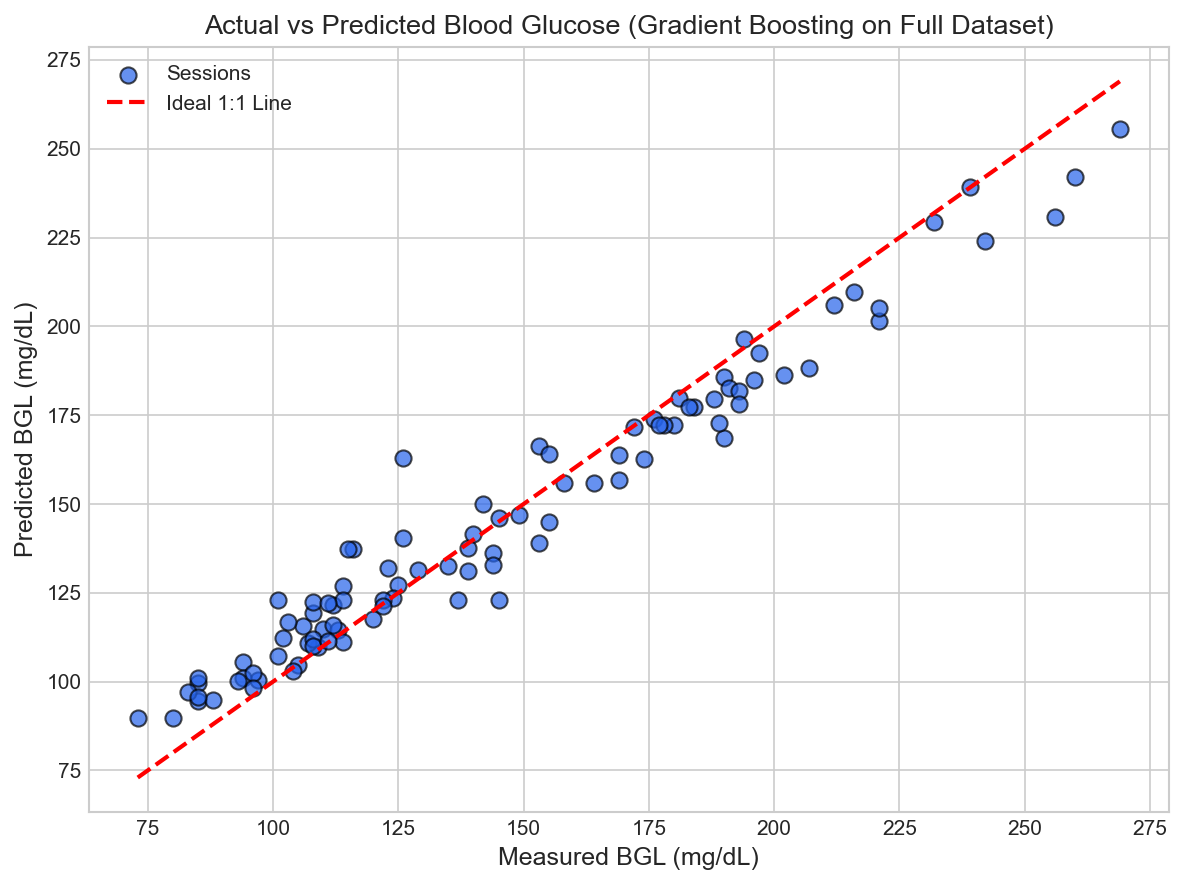

In [11]:
# Select final top 10 non-redundant features on full dataset
final_selected_features = select_features_on_fold_train(X_full_df, y, all_ppg_feature_names)
print(f"✓ Final Selected Features on Full Dataset ({len(final_selected_features)}): {final_selected_features}")

imp_final = SimpleImputer(strategy='mean')
X_final_imp = imp_final.fit_transform(X_full_df[final_selected_features])

full_dataset_results = []
trained_final_models = {}

for model_name, model in models.items():
    model.fit(X_final_imp, y)
    trained_final_models[model_name] = model
    
    preds = model.predict(X_final_imp)
    tr_mae = mean_absolute_error(y, preds)
    tr_rmse = np.sqrt(mean_squared_error(y, preds))
    tr_r2 = r2_score(y, preds)
    
    full_dataset_results.append({
        'Algorithm': model_name,
        'Full Dataset MAE (mg/dL)': f"{tr_mae:.2f}",
        'Full Dataset RMSE (mg/dL)': f"{tr_rmse:.2f}",
        'Full Dataset R^2': f"{tr_r2:.3f}"
    })

full_summary_df = pd.DataFrame(full_dataset_results)
print("\n=== Final Model Training Results (Full Dataset) ===")
display(full_summary_df)

# Plot Actual vs Predicted BGL for Best Model (Gradient Boosting / CatBoost)
best_model_name = 'Gradient Boosting'
best_preds = trained_final_models[best_model_name].predict(X_final_imp)

plt.figure(figsize=(8, 6))
plt.scatter(y, best_preds, alpha=0.7, color='#2563eb', edgecolors='k', s=60, label='Sessions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'Actual vs Predicted Blood Glucose ({best_model_name} on Full Dataset)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Subject-Grouped 90-10 Train-Test Split (Generalization Assessment)

To evaluate simple holdout generalization on unseen subjects, we perform a **subject-grouped 90-10 train-test split** (`GroupShuffleSplit`).
The holdout test set contains 10% of participants that are 100% unseen during training. Feature selection (`select_features_on_fold_train`) and imputer fitting are strictly isolated to the 90% training split to guarantee zero data leakage.

=== Subject-Grouped 90-10 Train-Test Split (Participant ID) ===
✓ Total Sessions: Train=77 (68 participants), Test=20 (17 participants)
✓ Test Participants (100% Unseen): ['P002', 'P034', 'P036', 'P041', 'P042', 'P048', 'P050', 'P052', 'P054', 'P055', 'P062', 'P064', 'P068', 'P078', 'P079', 'P082', 'P084']

✓ Selected Top Features on 90% Train Set (15): ['HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Mean', 'elasticity_index', 'HRV_PSS', 'HRV_IALS', 'HRV_MFDFA_alpha1_Peak', 'dc_component', 'b_a_ratio', 'HRV_SampEn', 'avg_apg_skew', 'HRV_CD', 'c_a_ratio', 'HRV_CVI', 'HRV_TINN']

=== 90-10 Subject-Grouped Train-Test Split Performance ===


,Algorithm,Train (90%) MAE,Train (90%) R^2,Test (10% Unseen) MAE,Test (10% Unseen) RMSE,Test (10% Unseen) R^2
0,Random Forest,23.46,0.642,43.54,54.50,-0.046
1,Gradient Boosting,8.19,0.952,46.04,58.42,-0.202
2,Extra Trees,28.17,0.485,43.76,54.42,-0.043
3,XGBoost,9.13,0.937,46.87,59.83,-0.261
4,Ridge Regression,35.90,0.122,45.15,55.24,-0.075
5,CatBoost,21.47,0.696,45.77,56.81,-0.137
6,LightGBM,25.58,0.493,44.23,57.17,-0.151


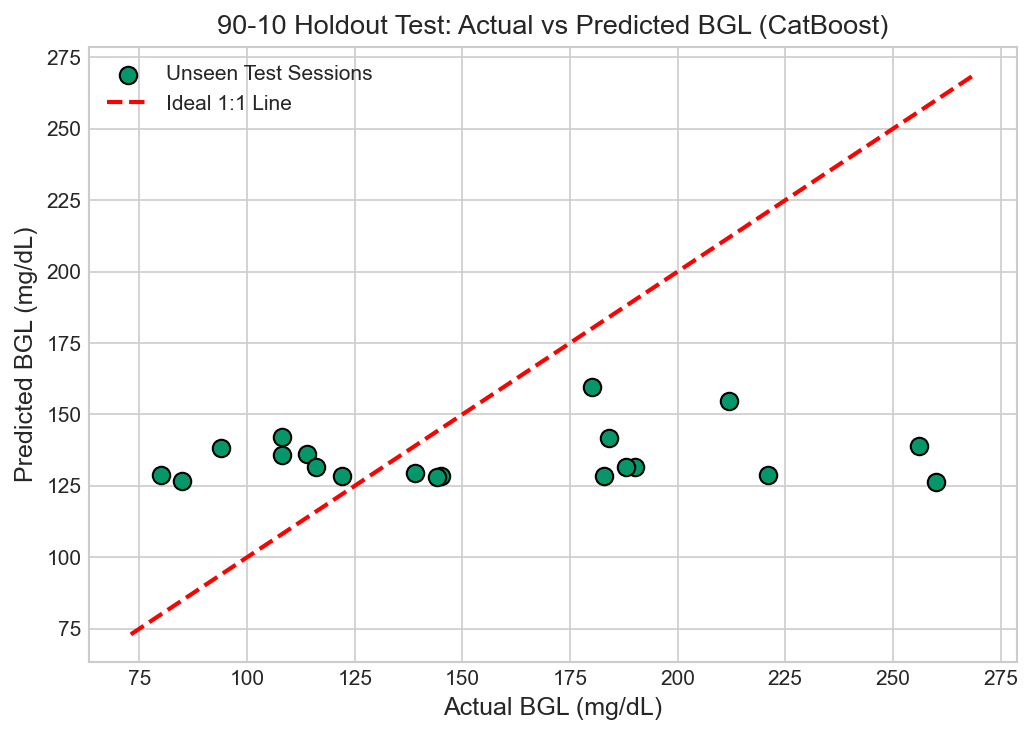

In [14]:
from sklearn.model_selection import GroupShuffleSplit

print("=== Subject-Grouped 90-10 Train-Test Split (Participant ID) ===")

# GroupShuffleSplit with 90-10 ratio (test_size=0.10) based on participant_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.20)
train_idx, test_idx = next(gss.split(X_full_df, y, groups=groups))

X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
X_te_df, y_te = X_full_df.iloc[test_idx].copy(), y[test_idx]

train_participants = set(groups[train_idx])
test_participants = set(groups[test_idx])

print(f"✓ Total Sessions: Train={len(train_idx)} ({len(train_participants)} participants), Test={len(test_idx)} ({len(test_participants)} participants)")
print(f"✓ Test Participants (100% Unseen): {sorted(list(test_participants))}\n")

# Zero-Leakage Feature Selection on 90% Training Split ONLY
split_selected_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names, max_features=15)
print(f"✓ Selected Top Features on 90% Train Set ({len(split_selected_feats)}): {split_selected_feats}\n")

# Imputer fit strictly on Train set
imp_split = SimpleImputer(strategy='mean')
X_tr_imp = imp_split.fit_transform(X_tr_df[split_selected_feats])
X_te_imp = imp_split.transform(X_te_df[split_selected_feats])

holdout_results = []

for model_name, model in models.items():
    # Fit model on 90% Train split
    model.fit(X_tr_imp, y_tr)
    
    # Predict on 90% Train split
    tr_preds = model.predict(X_tr_imp)
    tr_mae = mean_absolute_error(y_tr, tr_preds)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, tr_preds))
    tr_r2 = r2_score(y_tr, tr_preds)
    
    # Predict on 10% Unseen Test split
    te_preds = model.predict(X_te_imp)
    te_mae = mean_absolute_error(y_te, te_preds)
    te_rmse = np.sqrt(mean_squared_error(y_te, te_preds))
    te_r2 = r2_score(y_te, te_preds)
    
    holdout_results.append({
        'Algorithm': model_name,
        'Train (90%) MAE': f"{tr_mae:.2f}",
        'Train (90%) R^2': f"{tr_r2:.3f}",
        'Test (10% Unseen) MAE': f"{te_mae:.2f}",
        'Test (10% Unseen) RMSE': f"{te_rmse:.2f}",
        'Test (10% Unseen) R^2': f"{te_r2:.3f}"
    })

holdout_summary_df = pd.DataFrame(holdout_results)
print("=== 90-10 Subject-Grouped Train-Test Split Performance ===")
display(holdout_summary_df)

# Scatter Plot: Actual vs Predicted BGL on Unseen 10% Test Set for CatBoost / Best Model
best_test_model = 'CatBoost' if 'CatBoost' in models else 'Random Forest'
best_model_obj = models[best_test_model]
te_preds_best = best_model_obj.predict(X_te_imp)

plt.figure(figsize=(7, 5))
plt.scatter(y_te, te_preds_best, color='#059669', edgecolors='k', s=70, label='Unseen Test Sessions')
plt.plot([min(y_tr.min(), y_te.min()), max(y_tr.max(), y_te.max())], 
         [min(y_tr.min(), y_te.min()), max(y_tr.max(), y_te.max())], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Actual BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'90-10 Holdout Test: Actual vs Predicted BGL ({best_test_model})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


# 🩺 Clinical Reliability & Clarke Error Grid Analysis (EGA)

In clinical blood glucose monitoring, statistical metrics (MAE, RMSE, R²) are supplemented by **Clarke Error Grid Analysis (EGA)** to evaluate the potential clinical consequences of prediction errors.
- **Zone A (Clinical Accuracy)**: Predictions within 20% of reference value, leading to correct clinical decisions.
- **Zone B (Benign Errors)**: Errors outside Zone A that would not lead to inappropriate treatment.
- **Zone A + B (Clinical Acceptance Rate)**: The percentage of predictions within acceptable clinical bounds (target > 95%).


=== 🩺 Clarke Error Grid Analysis across Candidate Algorithms ===



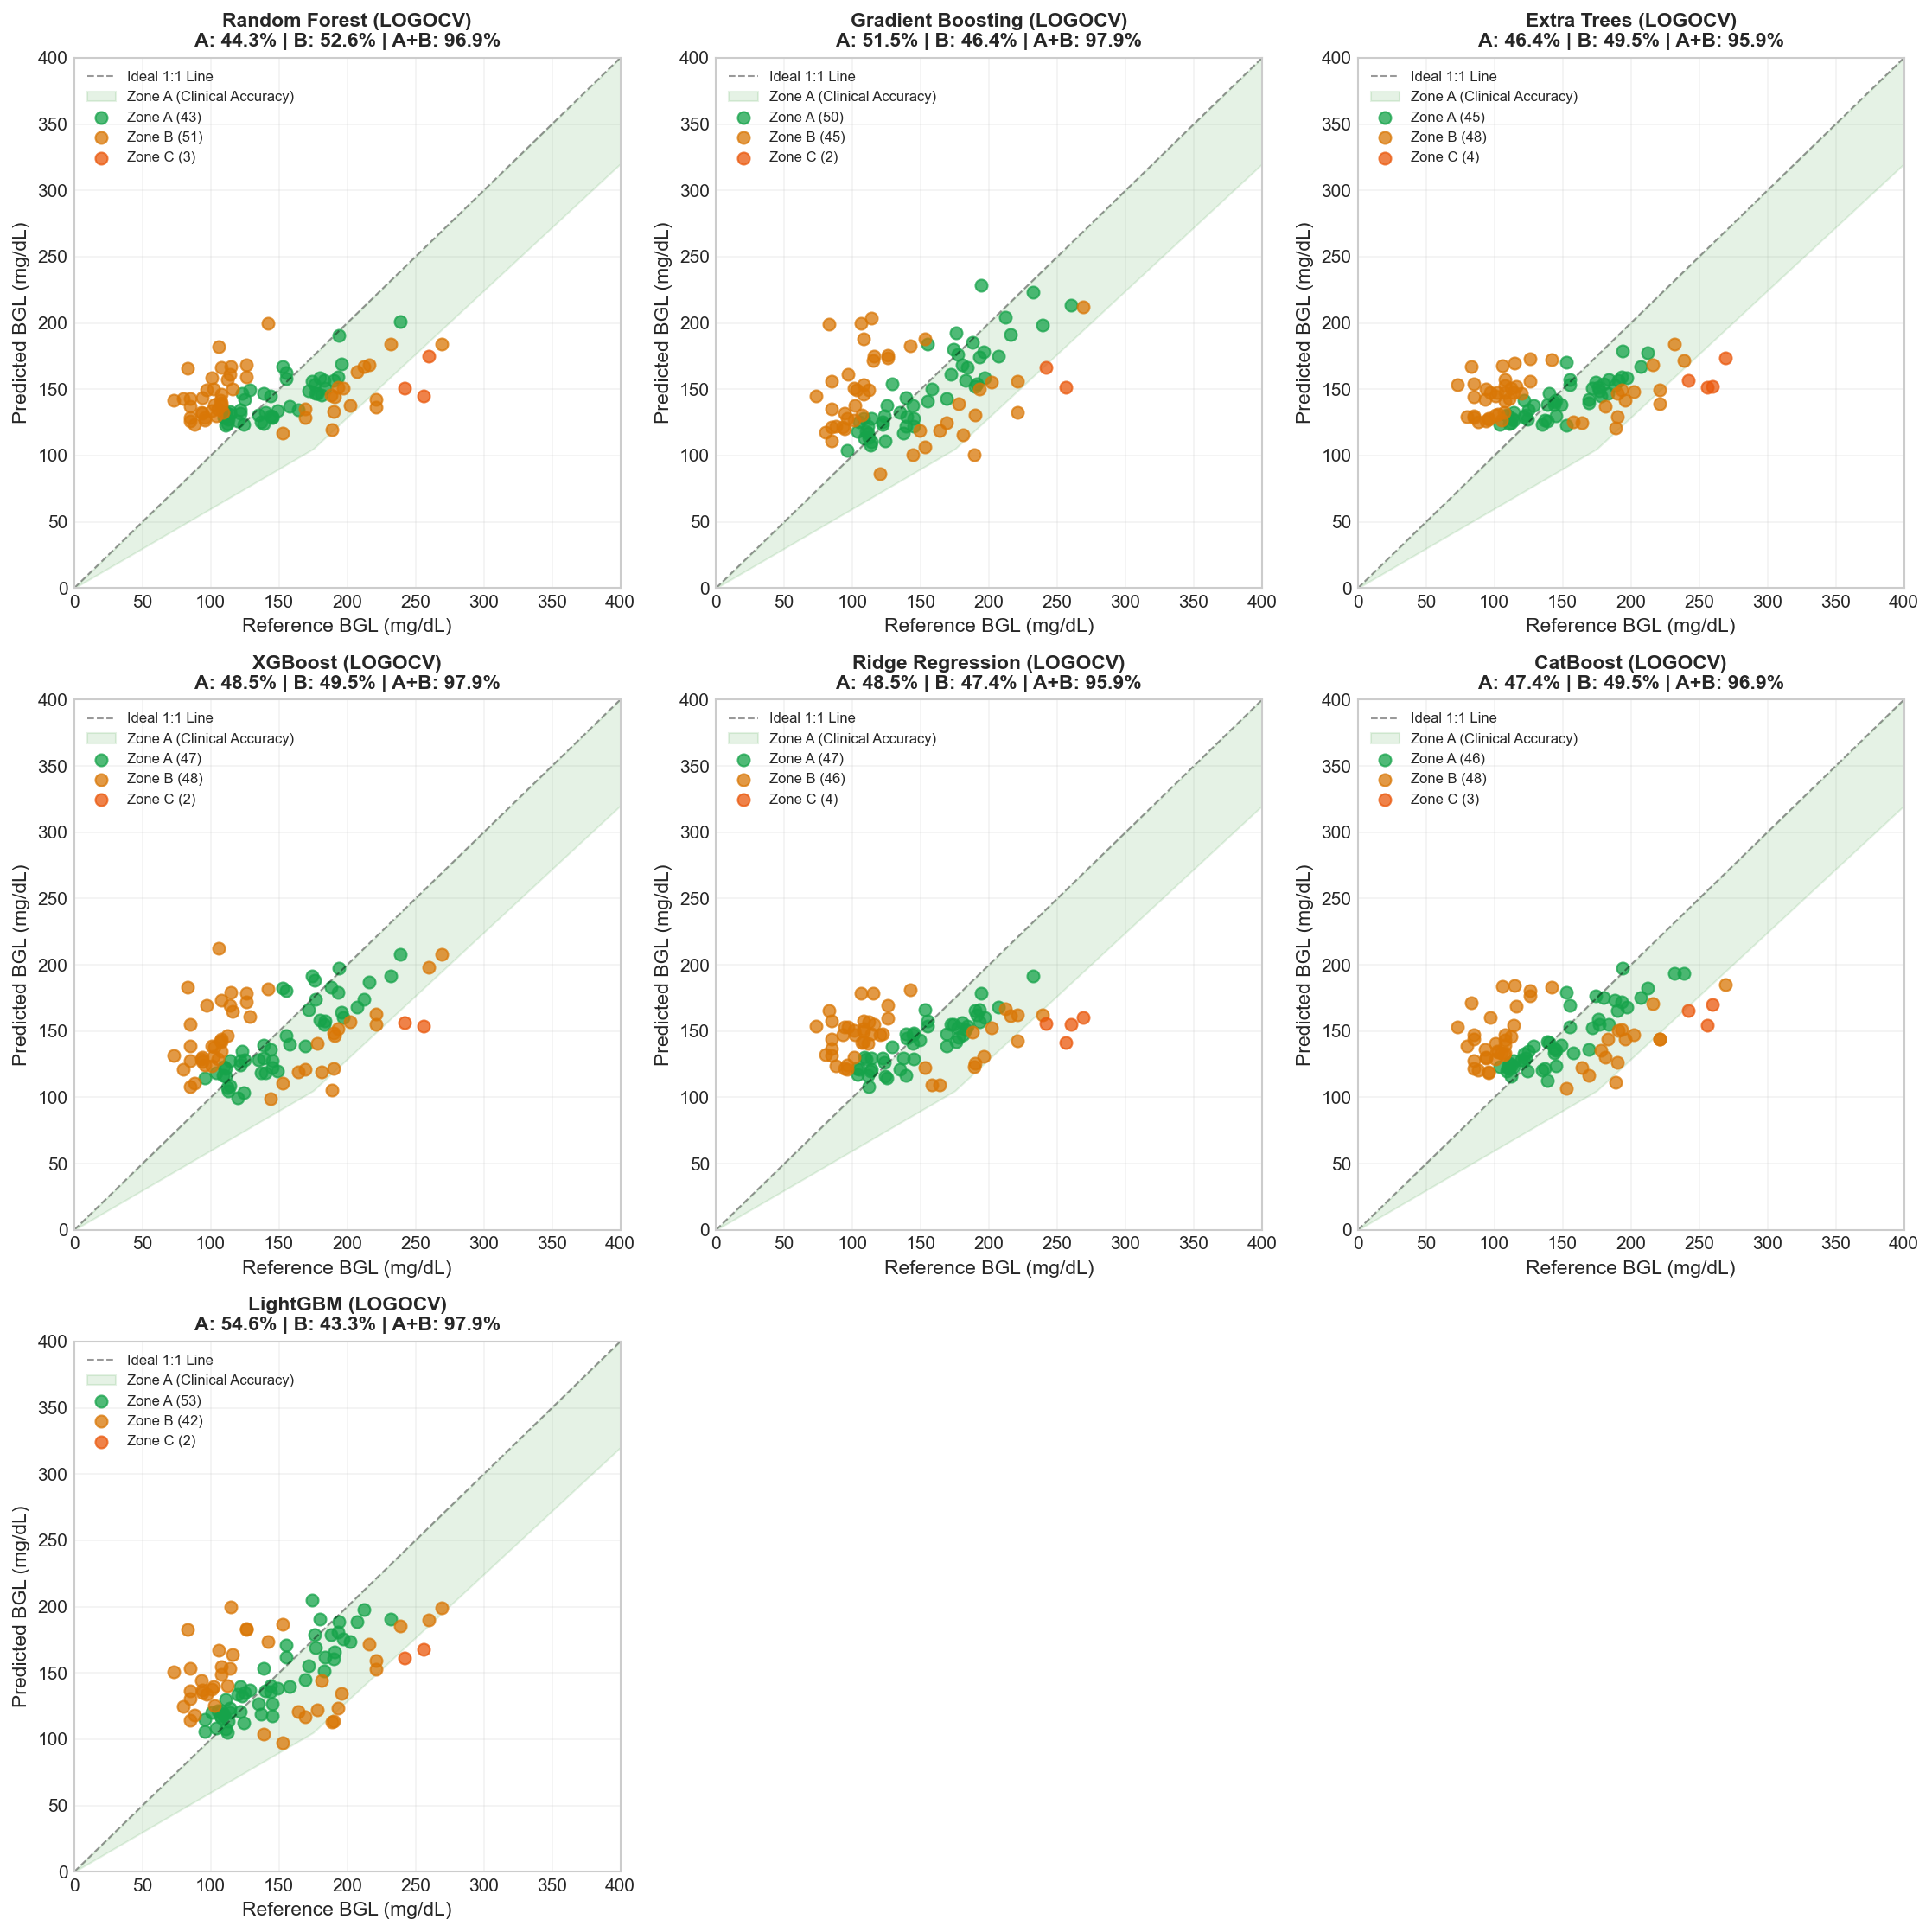


=== 📋 Clinical Reliability & Clarke Error Grid Summary (LOGOCV) ===


,Algorithm,LOGOCV Zone A (%),LOGOCV Zone B (%),LOGOCV Zone A+B (%),LOGOCV Zone C (%),LOGOCV Zone D (%),LOGOCV Zone E (%)
0,Random Forest,44.3%,52.6%,96.9%,3.1%,0.0%,0.0%
1,Gradient Boosting,51.5%,46.4%,97.9%,2.1%,0.0%,0.0%
2,Extra Trees,46.4%,49.5%,95.9%,4.1%,0.0%,0.0%
3,XGBoost,48.5%,49.5%,97.9%,2.1%,0.0%,0.0%
4,Ridge Regression,48.5%,47.4%,95.9%,4.1%,0.0%,0.0%
5,CatBoost,47.4%,49.5%,96.9%,3.1%,0.0%,0.0%
6,LightGBM,54.6%,43.3%,97.9%,2.1%,0.0%,0.0%


In [15]:
from IPython.display import display

print("=== 🩺 Clarke Error Grid Analysis across Candidate Algorithms ===\n")

# Generate multi-panel Clarke Error Grid plot for candidate models on LOGOCV predictions
n_models = len(models)
cols = min(3, n_models)
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

clarke_clinical_summary = []

for idx, (model_name, model) in enumerate(models.items()):
    # Compute LOGOCV Out-of-Fold Predictions
    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)

    # Compute Clarke Grid Metrics on LOGOCV
    fracs_logo = plot_clarke_grid(y, logo_preds, title=f"{model_name} (LOGOCV)", ax=axes[idx])

    clarke_clinical_summary.append({
        'Algorithm': model_name,
        'LOGOCV Zone A (%)': f"{fracs_logo['A']:.1f}%",
        'LOGOCV Zone B (%)': f"{fracs_logo['B']:.1f}%",
        'LOGOCV Zone A+B (%)': f"{fracs_logo['A'] + fracs_logo['B']:.1f}%",
        'LOGOCV Zone C (%)': f"{fracs_logo['C']:.1f}%",
        'LOGOCV Zone D (%)': f"{fracs_logo['D']:.1f}%",
        'LOGOCV Zone E (%)': f"{fracs_logo['E']:.1f}%"
    })

# Hide empty subplot axes if any
for i in range(n_models, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

ega_summary_df = pd.DataFrame(clarke_clinical_summary)
print("\n=== 📋 Clinical Reliability & Clarke Error Grid Summary (LOGOCV) ===")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(ega_summary_df)
